In [1]:
# ============================================================
# SETUP: Set Working Directory
# ============================================================
import os

# Go up one level from notebooks/ to Project1_DataScience/
os.chdir("..")

print(f"📂 Working directory: {os.getcwd()}")
print(f"\n📁 Files & folders:")
for item in os.listdir():
    print(f"   {item}")

📂 Working directory: C:\Users\LENOVO\Project1_DataScience

📁 Files & folders:
   .ipynb_checkpoints
   data
   notebooks
   outputs
   README.md
   screenshots


In [2]:
!pip install pandera

In [3]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import pandera as pa

print("✅ Tout est prêt !")

✅ Tout est prêt !


In [4]:
import os

# Créer tous les dossiers du projet
folders = [
    "data/raw",
    "data/clean",
    "notebooks",
    "screenshots",
    "outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ Dossier créé : {folder}")

✅ Dossier créé : data/raw
✅ Dossier créé : data/clean
✅ Dossier créé : notebooks
✅ Dossier créé : screenshots
✅ Dossier créé : outputs


In [5]:
readme = """# 🔬 Data Science Project 1 — Advanced EDA & Feature Engineering
### DecodeLabs Industrial Training Kit | Batch 2026

![Python](https://img.shields.io/badge/Python-3.10-blue)
![Pandas](https://img.shields.io/badge/Pandas-2.0-green)
![Status](https://img.shields.io/badge/Status-In%20Progress-yellow)

---

## 📌 Project Overview
This project is part of the **DecodeLabs Data Science Internship 2026**.  
The goal is to master **Advanced EDA & Feature Engineering** by transforming 
raw, chaotic data into a clean, production-ready dataset using enterprise-grade techniques.

---

## 🎯 Objectives
- Handle missing values using statistical imputation (Mean/Median/KNN)
- Detect and neutralize outliers using IQR (Winsorization)
- Engineer at least 3 new predictive features
- Validate data quality using Pandera schemas
- Build a vectorized, production-ready pipeline

---

## 🛠️ Tech Stack
| Tool | Purpose |
|------|---------|
| Python 3.10 | Core language |
| Pandas | Data manipulation |
| NumPy | Vectorized operations |
| Scikit-learn | KNN Imputation |
| Pandera | Data validation contracts |
| Matplotlib/Seaborn | Visualizations |
| Jupyter Notebook | Development environment |

---

## 📁 Project Structure
project1/

├── data/

│   ├── raw/          # Original dataset (untouched)

│   └── clean/        # Cleaned & validated dataset

├── notebooks/

│   └── project1_eda.ipynb   # Main notebook

├── screenshots/      # Visualizations & outputs

├── outputs/          # Final CSV & Parquet files

└── README.md

---

## 🔄 Pipeline Architecture (IPO Model)

### MODULE 1 — INPUT (Securing Fidelity)
- Calculate missingness % per feature
- Apply decision matrix: Drop / Median / KNN
- Cap outliers using IQR boundaries (Winsorization)

### MODULE 2 — PROCESS (Vectorized Engine)
- One-Hot Encoding for categorical variables
- Collinearity eradication (threshold: 0.80)
- Engineer 3+ new predictive features

### MODULE 3 — OUTPUT (Contracts & Serving)
- Pandera schema validation
- Export to CSV + Parquet
- Feature store ready

---

## 📊 Screenshots
*(Will be added after execution)*

---

## ✅ Results
*(Will be updated after project completion)*

---

## 👩‍💻 Author
**Imen Hammami**  
Data Science Intern @ DecodeLabs 2026  
🔗 [Portfolio](https://loquacious-travesseiro-9ec5ba.netlify.app/)  
🔗 [LinkedIn](https://www.linkedin.com/in/hammami-imen-939559221/)
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("✅ README.md créé avec succès !")

✅ README.md créé avec succès !


✅ Dataset loaded successfully!

📐 Dimensions: 1200 rows × 14 columns

👀 First 5 rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10

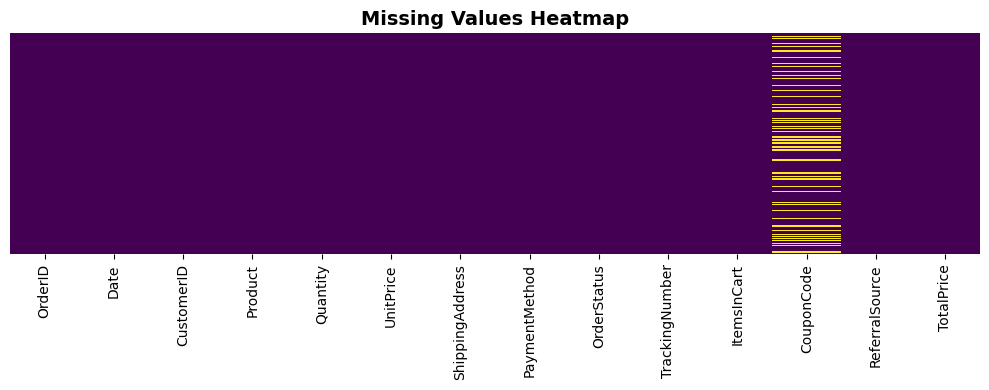

📸 Screenshot saved → screenshots/missing_values_heatmap.png


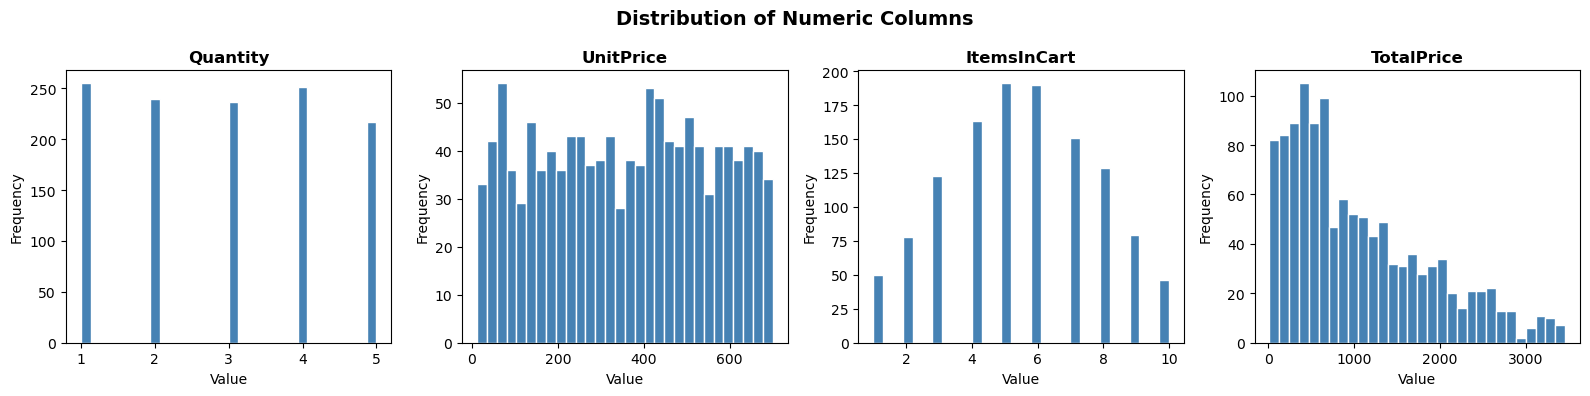

📸 Screenshot saved → screenshots/numeric_distributions.png

✅ STEP 1 COMPLETE — Ready for Step 2: Data Cleaning


In [6]:
# ============================================================
# PROJECT 1: Advanced EDA & Feature Engineering
# DecodeLabs Industrial Training Kit | Batch 2026
# Author: Imen Hammami
# ============================================================

# ============================================================
# STEP 1: DATA LOADING & EXPLORATION
# ------------------------------------------------------------
# Goal: Load the dataset and understand its structure before
# touching anything. Like a doctor doing a checkup first!
# Tools: Pandas, NumPy, Matplotlib, Seaborn
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1.1 Load the Excel file ---
df = pd.read_excel("data/raw/Dataset for Data Analytics.xlsx")

print("=" * 60)
print("✅ Dataset loaded successfully!")
print("=" * 60)

# --- 1.2 Shape of the dataset ---
print(f"\n📐 Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")

# --- 1.3 First look at the data ---
print("\n👀 First 5 rows:")
print(df.head())

# --- 1.4 Column data types ---
print("\n📋 Data Types:")
print(df.dtypes)

# --- 1.5 General statistics ---
print("\n📊 Statistical Summary:")
print(df.describe())

# --- 1.6 Missing values analysis ---
print("\n❓ Missing Values (%):")
missing = df.isnull().mean() * 100
missing_report = missing[missing > 0].sort_values(ascending=False)
if missing_report.empty:
    print("   No missing values found!")
else:
    print(missing_report)

# --- 1.7 Unique values per column ---
print("\n🔢 Unique Values per Column:")
for col in df.columns:
    print(f"   {col}: {df[col].nunique()} unique values")

# --- 1.8 Visualize Missing Values ---
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("screenshots/missing_values_heatmap.png", dpi=150)
plt.show()
print("📸 Screenshot saved → screenshots/missing_values_heatmap.png")

# --- 1.9 Distribution of numeric columns ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Distribution of Numeric Columns", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("screenshots/numeric_distributions.png", dpi=150)
plt.show()
print("📸 Screenshot saved → screenshots/numeric_distributions.png")

print("\n" + "=" * 60)
print("✅ STEP 1 COMPLETE — Ready for Step 2: Data Cleaning")
print("=" * 60)

🧹 STEP 2: DATA CLEANING

🗑️  2A — Dropped identifier columns: ['OrderID', 'CustomerID', 'ShippingAddress', 'TrackingNumber']
     New shape: 1200 rows × 10 columns

✅ 2B — Missing Values handled:
     CouponCode: 309 missing → filled with 'No_Coupon'
     Missing values remaining: 0
     Total missing in dataset: 0

📊 2C — Outlier Detection & Neutralization (IQR Winsorization):
------------------------------------------------------------
   Quantity        |   0 outliers capped | [-1.00 → 7.00]
   UnitPrice       |   0 outliers capped | [-317.20 → 1024.83]
   ItemsInCart     |   0 outliers capped | [-0.50 → 11.50]
   TotalPrice      |   8 outliers capped | [-1341.41 → 3330.41]


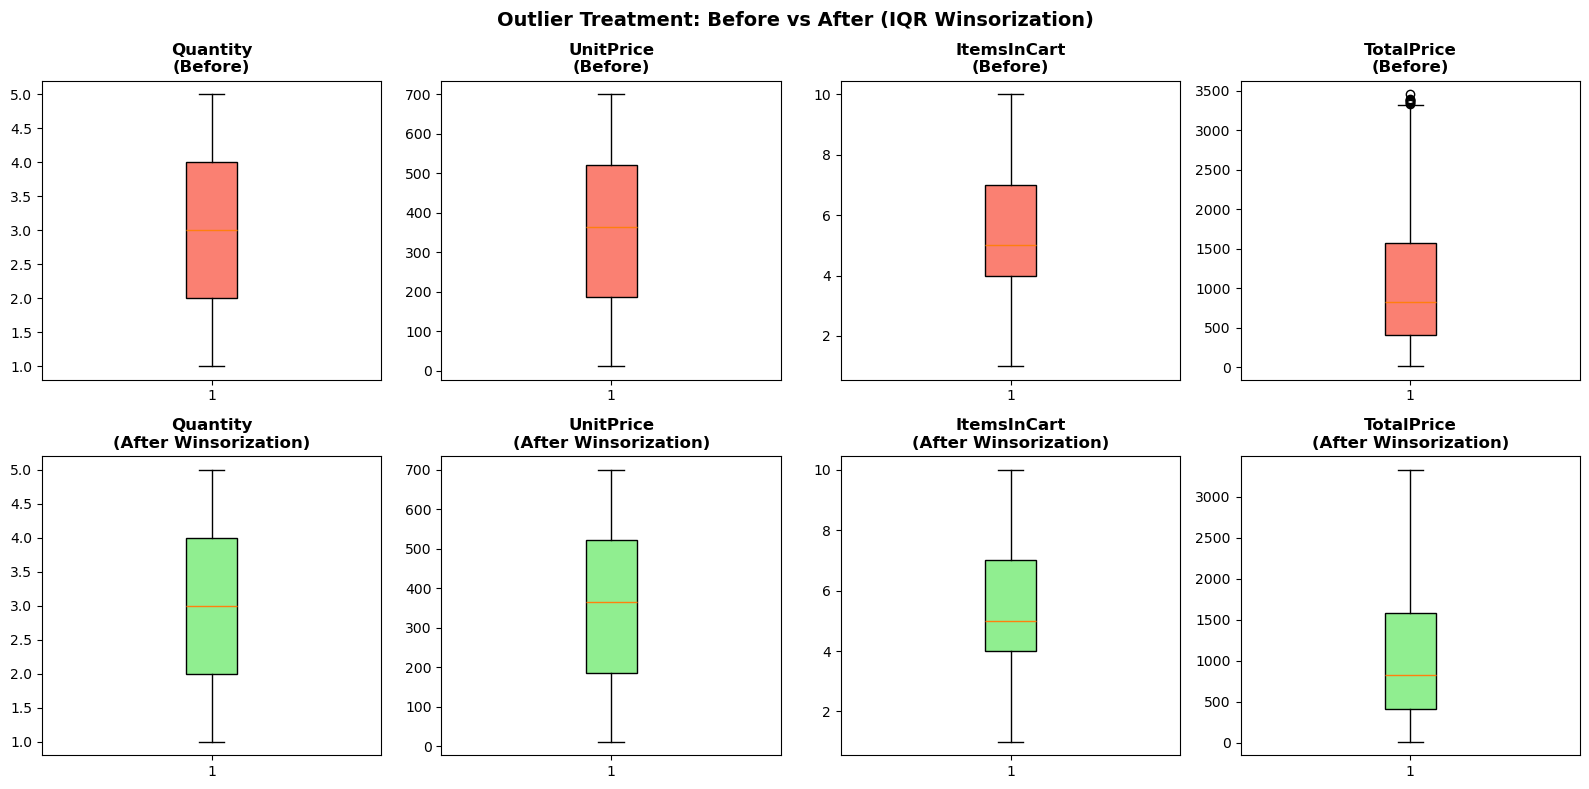


📸 Screenshot saved → screenshots/outliers_before_after.png

📅 2D — Date column extracted into 4 features:
     → Year, Month, DayOfWeek, Quarter
     Original 'Date' column dropped

✅ STEP 2 COMPLETE — Data Cleaning Summary:
   Rows:            1200 (none deleted!)
   Columns:         13
   Missing values:  0
   Outliers capped: 8

👀 Clean Dataset Preview:
   Product  Quantity  UnitPrice PaymentMethod OrderStatus  ItemsInCart  \
0  Monitor         5     570.62    Debit Card     Shipped            7   
1    Phone         2     151.35        Online     Shipped            3   
2   Tablet         5     550.68   Credit Card   Cancelled            8   

  CouponCode ReferralSource  TotalPrice  Year  Month  DayOfWeek  Quarter  
0     SAVE10      Instagram      2853.1  2023      1          2        1  
1     SAVE10       Referral       302.7  2024      8          4        3  
2   FREESHIP          Email      2753.4  2024      2          1        1  

📋 Current Columns: ['Product', 'Quantity',

In [7]:
# ============================================================
# STEP 2: DATA CLEANING
# ------------------------------------------------------------
# Goal: Fix all data quality issues before any transformation
# What we do:
#   2A → Drop useless identifier columns
#   2B → Handle missing values (CouponCode: 25.75% → "No_Coupon")
#   2C → Detect & neutralize outliers using IQR Winsorization
#   2D → Extract useful features from the Date column
# Why Winsorization? We CAP outliers instead of deleting rows
#      → We keep all 1200 rows intact!
# ============================================================

print("=" * 60)
print("🧹 STEP 2: DATA CLEANING")
print("=" * 60)

# Save raw backup
df_raw = df.copy()

# ----------------------------------------
# 2A. DROP IDENTIFIER COLUMNS
# ----------------------------------------
# These columns are unique IDs — they carry
# zero predictive value for any ML model

cols_to_drop = ['OrderID', 'CustomerID', 'ShippingAddress', 'TrackingNumber']
df = df.drop(columns=cols_to_drop)

print(f"\n🗑️  2A — Dropped identifier columns: {cols_to_drop}")
print(f"     New shape: {df.shape[0]} rows × {df.shape[1]} columns")

# ----------------------------------------
# 2B. HANDLE MISSING VALUES
# ----------------------------------------
# CouponCode: 25.75% missing
# → It's a text column, KNN doesn't apply
# → Missing = customer simply had no coupon
# → Strategy: fill with 'No_Coupon'

before = df['CouponCode'].isnull().sum()
df['CouponCode'] = df['CouponCode'].fillna('No_Coupon')
after = df['CouponCode'].isnull().sum()

print(f"\n✅ 2B — Missing Values handled:")
print(f"     CouponCode: {before} missing → filled with 'No_Coupon'")
print(f"     Missing values remaining: {after}")
print(f"     Total missing in dataset: {df.isnull().sum().sum()}")

# ----------------------------------------
# 2C. OUTLIER DETECTION & NEUTRALIZATION
# ----------------------------------------
# Method: IQR (Interquartile Range)
# Formula:
#   IQR = Q3 - Q1
#   Lower bound = Q1 - 1.5 * IQR
#   Upper bound = Q3 + 1.5 * IQR
# Action: Winsorization → clip values at bounds
# Why not delete? Keeps all 1200 rows intact!

numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

print(f"\n📊 2C — Outlier Detection & Neutralization (IQR Winsorization):")
print("-" * 60)

outlier_report = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    
    outlier_report.append({
        'Column': col,
        'Outliers Found': outliers,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    })
    print(f"   {col:15} | {outliers:3} outliers capped | [{lower:.2f} → {upper:.2f}]")

# Visualize before vs after outliers
fig, axes = plt.subplots(2, len(numeric_cols), figsize=(16, 8))

for i, col in enumerate(numeric_cols):
    # Before (from raw backup)
    axes[0, i].boxplot(df_raw[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='salmon'))
    axes[0, i].set_title(f"{col}\n(Before)", fontweight='bold')
    
    # After
    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='lightgreen'))
    axes[1, i].set_title(f"{col}\n(After Winsorization)", fontweight='bold')

plt.suptitle("Outlier Treatment: Before vs After (IQR Winsorization)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("screenshots/outliers_before_after.png", dpi=150)
plt.show()
print("\n📸 Screenshot saved → screenshots/outliers_before_after.png")

# ----------------------------------------
# 2D. DATE FEATURE EXTRACTION
# ----------------------------------------
# ML models cannot read raw dates like "2023-01-04"
# We convert the Date column into 4 numeric features
# that capture time-based patterns

df['Year']      = df['Date'].dt.year
df['Month']     = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Quarter']   = df['Date'].dt.quarter
df = df.drop(columns=['Date'])

print(f"\n📅 2D — Date column extracted into 4 features:")
print(f"     → Year, Month, DayOfWeek, Quarter")
print(f"     Original 'Date' column dropped")

# ----------------------------------------
# STEP 2 SUMMARY
# ----------------------------------------
print(f"\n{'=' * 60}")
print(f"✅ STEP 2 COMPLETE — Data Cleaning Summary:")
print(f"   Rows:            {df.shape[0]} (none deleted!)")
print(f"   Columns:         {df.shape[1]}")
print(f"   Missing values:  {df.isnull().sum().sum()}")
print(f"   Outliers capped: {sum([r['Outliers Found'] for r in outlier_report])}")
print(f"\n👀 Clean Dataset Preview:")
print(df.head(3))
print(f"\n📋 Current Columns: {list(df.columns)}")
print(f"{'=' * 60}")
print("➡️  Ready for Step 3: Feature Engineering")

⚙️  STEP 3: FEATURE ENGINEERING

✅ 3A — Revenue_Per_Item created
     Formula: TotalPrice / Quantity
     Mean: $356.35
     Min:  $11.39
     Max:  $699.93

✅ 3B — Is_Weekend created (0=Weekday, 1=Weekend)
     Weekend orders: 358 (29.8%)
     Weekday orders: 842 (70.2%)

✅ 3C — Has_Coupon created (0=No Coupon, 1=Has Coupon)
     Customers with coupon:    891 (74.2%)
     Customers without coupon: 309 (25.8%)

✅ 3D — Price_Quantity_Ratio created
     Formula: UnitPrice / Quantity
     Mean: 165.33


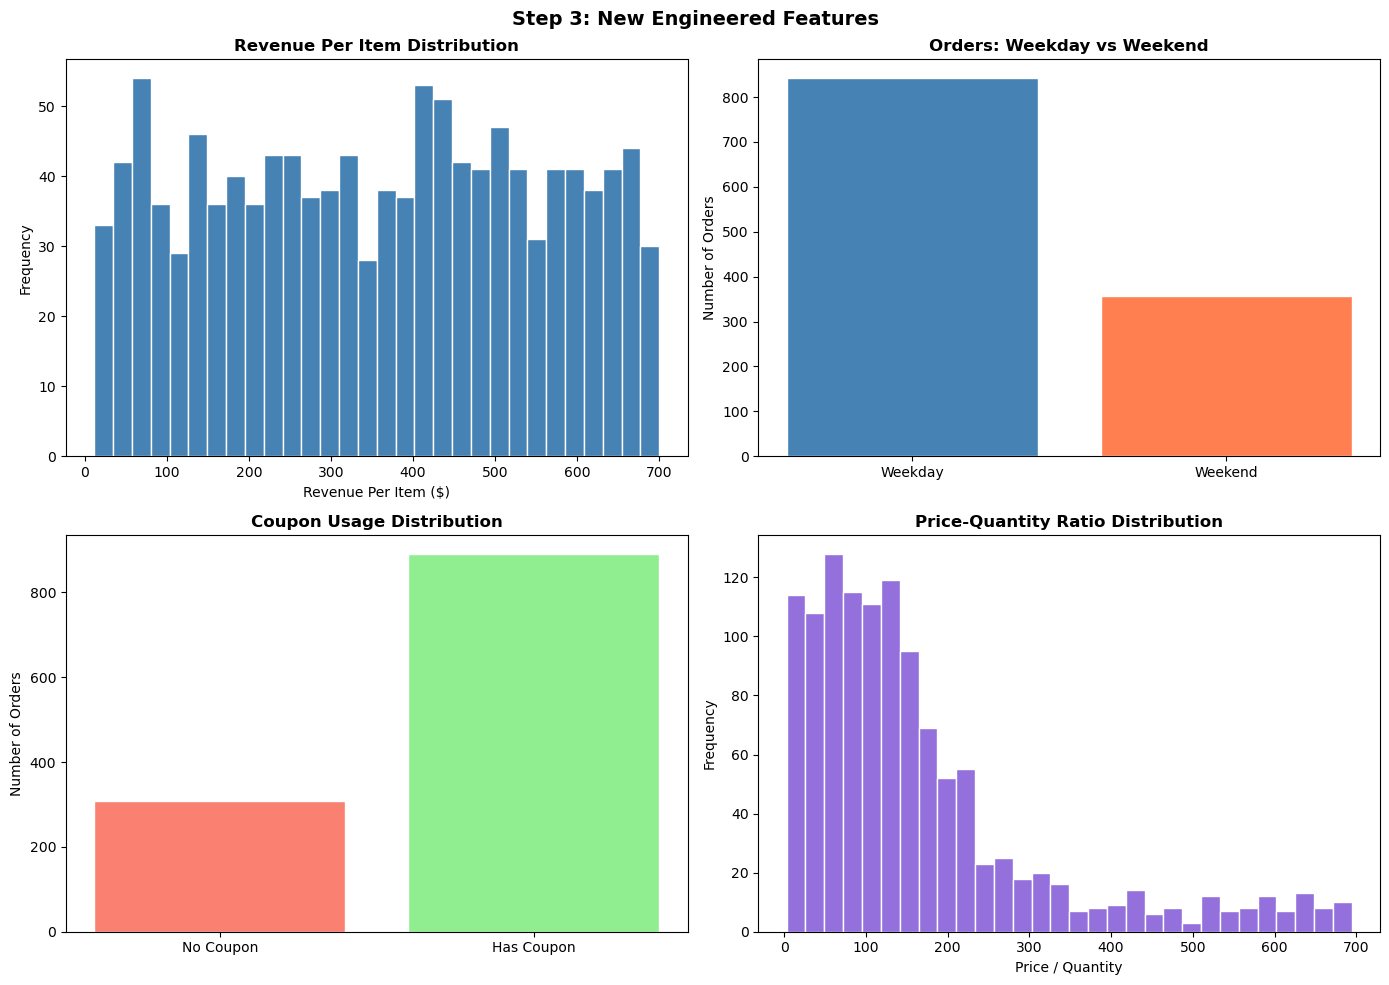


📸 Screenshot saved → screenshots/engineered_features.png

✅ STEP 3 COMPLETE — Feature Engineering Summary:
   New features created: 4
   → Revenue_Per_Item
   → Is_Weekend
   → Has_Coupon
   → Price_Quantity_Ratio
   Total columns now: 17

👀 Preview with new features:
   Revenue_Per_Item  Is_Weekend  Has_Coupon  Price_Quantity_Ratio
0            570.62           0           1               114.124
1            151.35           0           1                75.675
2            550.68           0           1               110.136
➡️  Ready for Step 4: Encoding + Collinearity Check


In [8]:
# ============================================================
# STEP 3: FEATURE ENGINEERING
# ------------------------------------------------------------
# Goal: Create 3+ new predictive features from existing data
# Why? We give the ML model extra signals it can't see alone
#
# New Features:
#   3A → Revenue_Per_Item     (TotalPrice / Quantity)
#   3B → Is_Weekend           (was order on Sat/Sun?)
#   3C → Has_Coupon           (did customer use coupon?)
#   3D → Price_Quantity_Ratio (UnitPrice / Quantity)
# ============================================================

print("=" * 60)
print("⚙️  STEP 3: FEATURE ENGINEERING")
print("=" * 60)

df_before = df.copy()

# ----------------------------------------
# 3A. REVENUE PER ITEM
# ----------------------------------------
# Logic: TotalPrice / Quantity
# Why useful? A high TotalPrice with 1 item
# is very different from the same price with 5 items
# It reveals the "true value" of each order line

df['Revenue_Per_Item'] = df['TotalPrice'] / df['Quantity']

print(f"\n✅ 3A — Revenue_Per_Item created")
print(f"     Formula: TotalPrice / Quantity")
print(f"     Mean: ${df['Revenue_Per_Item'].mean():.2f}")
print(f"     Min:  ${df['Revenue_Per_Item'].min():.2f}")
print(f"     Max:  ${df['Revenue_Per_Item'].max():.2f}")

# ----------------------------------------
# 3B. IS WEEKEND
# ----------------------------------------
# Logic: DayOfWeek >= 5 → Saturday(5) or Sunday(6)
# Why useful? Customer behavior changes on weekends
# People buy more leisure items, spend more, etc.

df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)

weekend_orders = df['Is_Weekend'].sum()
print(f"\n✅ 3B — Is_Weekend created (0=Weekday, 1=Weekend)")
print(f"     Weekend orders: {weekend_orders} ({weekend_orders/len(df)*100:.1f}%)")
print(f"     Weekday orders: {len(df)-weekend_orders} ({(len(df)-weekend_orders)/len(df)*100:.1f}%)")

# ----------------------------------------
# 3C. HAS COUPON
# ----------------------------------------
# Logic: If CouponCode != 'No_Coupon' → 1, else 0
# Why useful? Coupon users behave differently
# They may buy more, return less, or be more loyal

df['Has_Coupon'] = (df['CouponCode'] != 'No_Coupon').astype(int)

coupon_users = df['Has_Coupon'].sum()
print(f"\n✅ 3C — Has_Coupon created (0=No Coupon, 1=Has Coupon)")
print(f"     Customers with coupon:    {coupon_users} ({coupon_users/len(df)*100:.1f}%)")
print(f"     Customers without coupon: {len(df)-coupon_users} ({(len(df)-coupon_users)/len(df)*100:.1f}%)")

# ----------------------------------------
# 3D. PRICE QUANTITY RATIO
# ----------------------------------------
# Logic: UnitPrice / Quantity
# Why useful? Captures the "premium vs bulk" behavior
# High ratio = buying expensive items in small qty
# Low ratio  = buying cheap items in large qty

df['Price_Quantity_Ratio'] = df['UnitPrice'] / df['Quantity']

print(f"\n✅ 3D — Price_Quantity_Ratio created")
print(f"     Formula: UnitPrice / Quantity")
print(f"     Mean: {df['Price_Quantity_Ratio'].mean():.2f}")

# ----------------------------------------
# VISUALIZE NEW FEATURES
# ----------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Revenue Per Item distribution
axes[0,0].hist(df['Revenue_Per_Item'], bins=30,
               color='steelblue', edgecolor='white')
axes[0,0].set_title('Revenue Per Item Distribution',
                     fontweight='bold')
axes[0,0].set_xlabel('Revenue Per Item ($)')
axes[0,0].set_ylabel('Frequency')

# Weekend vs Weekday orders
weekend_counts = df['Is_Weekend'].value_counts()
axes[0,1].bar(['Weekday', 'Weekend'],
              [weekend_counts.get(0,0), weekend_counts.get(1,0)],
              color=['steelblue', 'coral'], edgecolor='white')
axes[0,1].set_title('Orders: Weekday vs Weekend',
                     fontweight='bold')
axes[0,1].set_ylabel('Number of Orders')

# Coupon usage
coupon_counts = df['Has_Coupon'].value_counts()
axes[1,0].bar(['No Coupon', 'Has Coupon'],
              [coupon_counts.get(0,0), coupon_counts.get(1,0)],
              color=['salmon', 'lightgreen'], edgecolor='white')
axes[1,0].set_title('Coupon Usage Distribution',
                     fontweight='bold')
axes[1,0].set_ylabel('Number of Orders')

# Price Quantity Ratio
axes[1,1].hist(df['Price_Quantity_Ratio'], bins=30,
               color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Price-Quantity Ratio Distribution',
                     fontweight='bold')
axes[1,1].set_xlabel('Price / Quantity')
axes[1,1].set_ylabel('Frequency')

plt.suptitle('Step 3: New Engineered Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("screenshots/engineered_features.png", dpi=150)
plt.show()
print("\n📸 Screenshot saved → screenshots/engineered_features.png")

# ----------------------------------------
# STEP 3 SUMMARY
# ----------------------------------------
new_features = ['Revenue_Per_Item', 'Is_Weekend',
                'Has_Coupon', 'Price_Quantity_Ratio']

print(f"\n{'=' * 60}")
print(f"✅ STEP 3 COMPLETE — Feature Engineering Summary:")
print(f"   New features created: {len(new_features)}")
for f in new_features:
    print(f"   → {f}")
print(f"   Total columns now: {df.shape[1]}")
print(f"\n👀 Preview with new features:")
print(df[new_features].head(3))
print(f"{'=' * 60}")
print("➡️  Ready for Step 4: Encoding + Collinearity Check")

🔢 STEP 4: ENCODING + COLLINEARITY CHECK

🔤 4A — Categorical columns to encode:
     Product: 7 unique values → ['Monitor', 'Phone', 'Tablet', 'Chair', 'Printer', 'Laptop', 'Desk']
     PaymentMethod: 5 unique values → ['Debit Card', 'Online', 'Credit Card', 'Gift Card', 'Cash']
     OrderStatus: 5 unique values → ['Shipped', 'Cancelled', 'Returned', 'Delivered', 'Pending']
     CouponCode: 4 unique values → ['SAVE10', 'FREESHIP', 'No_Coupon', 'WINTER15']
     ReferralSource: 5 unique values → ['Instagram', 'Referral', 'Email', 'Facebook', 'Google']

✅ One-Hot Encoding applied!
   Columns before encoding: 17
   Columns after encoding:  33
   New columns created: 16

🔍 4B — Collinearity Check (threshold: 0.80):
------------------------------------------------------------
   ⚠️  Month ↔ Quarter: correlation = 0.969 → drop 'Quarter'
   ⚠️  UnitPrice ↔ Revenue_Per_Item: correlation = 1.000 → drop 'Revenue_Per_Item'
   ⚠️  Has_Coupon ↔ CouponCode_No_Coupon: correlation = 1.000 → drop 'Has_Co

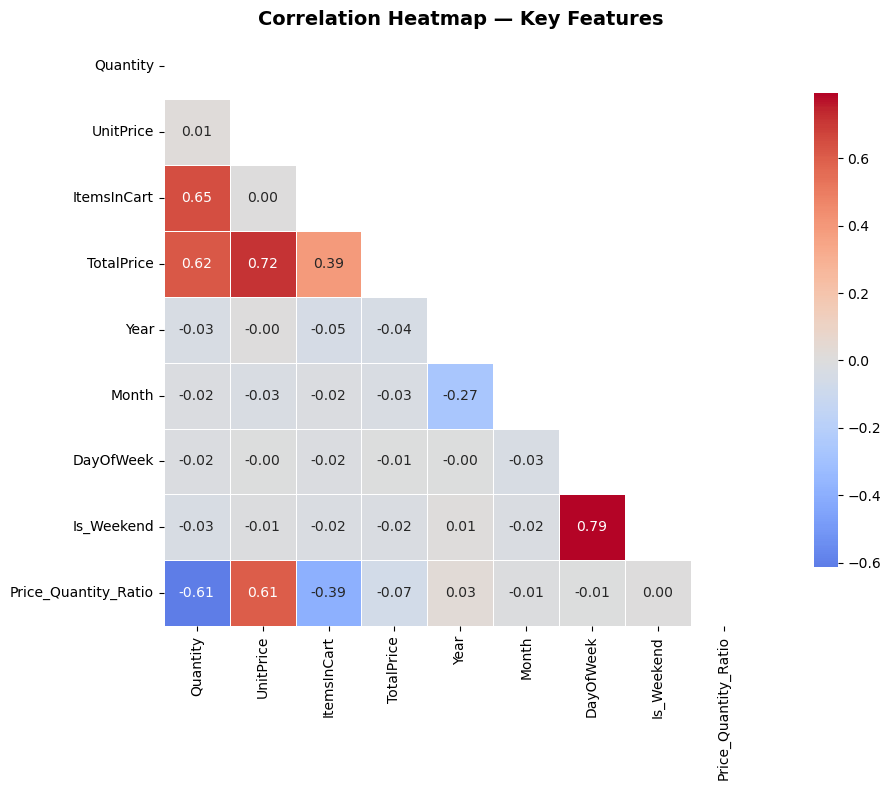


📸 Screenshot saved → screenshots/correlation_heatmap.png

✅ STEP 4 COMPLETE — Encoding & Collinearity Summary:
   Categorical columns encoded: 5
   Correlated columns dropped:  3
   Final column count:          30
   Final row count:             1200

👀 Final Dataset Preview:
   Quantity  UnitPrice  ItemsInCart  TotalPrice  Year  Month  DayOfWeek  \
0         5     570.62            7      2853.1  2023      1          2   
1         2     151.35            3       302.7  2024      8          4   
2         5     550.68            8      2753.4  2024      2          1   

   Is_Weekend  Price_Quantity_Ratio  Product_Desk  ...  OrderStatus_Pending  \
0           0               114.124             0  ...                    0   
1           0                75.675             0  ...                    0   
2           0               110.136             0  ...                    0   

   OrderStatus_Returned  OrderStatus_Shipped  CouponCode_No_Coupon  \
0                     0           

In [9]:
# ============================================================
# STEP 4: ENCODING + COLLINEARITY CHECK
# ------------------------------------------------------------
# Goal: Convert ALL text columns to numbers
#       Then remove columns that are too correlated (> 0.80)
#
# 4A → One-Hot Encoding for categorical columns
#       Why OHE and not Label Encoding?
#       Label Encoding: Paris=1, Tokyo=3 → Tokyo "worth more"?
#       One-Hot Encoding: each category gets its own 0/1 column
#       → No false hierarchy between categories!
#
# 4B → Collinearity Eradication
#       If 2 columns say the same thing → keep the better one
#       Threshold: correlation > 0.80 = too similar → drop!
# ============================================================

print("=" * 60)
print("🔢 STEP 4: ENCODING + COLLINEARITY CHECK")
print("=" * 60)

# ----------------------------------------
# 4A. ONE-HOT ENCODING
# ----------------------------------------
# These are our text (categorical) columns:
# Product, PaymentMethod, OrderStatus,
# CouponCode, ReferralSource

categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus',
                    'CouponCode', 'ReferralSource']

print(f"\n🔤 4A — Categorical columns to encode:")
for col in categorical_cols:
    print(f"     {col}: {df[col].nunique()} unique values → {list(df[col].unique())}")

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert boolean columns to int (0/1)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"\n✅ One-Hot Encoding applied!")
print(f"   Columns before encoding: {df.shape[1]}")
print(f"   Columns after encoding:  {df_encoded.shape[1]}")
print(f"   New columns created: {df_encoded.shape[1] - df.shape[1]}")

# ----------------------------------------
# 4B. COLLINEARITY CHECK
# ----------------------------------------
# Build correlation matrix on numeric columns
# Find pairs with correlation > 0.80
# Keep the one more correlated with TotalPrice
# Drop the weaker one

print(f"\n🔍 4B — Collinearity Check (threshold: 0.80):")
print("-" * 60)

# Calculate absolute correlation matrix
corr_matrix = df_encoded.corr().abs()

# Get upper triangle only (avoid duplicate pairs)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find correlated pairs > 0.80
correlated_pairs = []
cols_to_drop_corr = []

for col in upper.columns:
    correlated_with = upper.index[upper[col] > 0.80].tolist()
    for row in correlated_with:
        corr_val = corr_matrix.loc[row, col]
        
        # Keep the one more correlated with TotalPrice
        corr_A = corr_matrix.loc[row, 'TotalPrice'] if row != 'TotalPrice' else 1
        corr_B = corr_matrix.loc[col, 'TotalPrice'] if col != 'TotalPrice' else 1
        drop_col = row if corr_A < corr_B else col
        
        correlated_pairs.append((row, col, round(corr_val, 3)))
        if drop_col not in cols_to_drop_corr:
            cols_to_drop_corr.append(drop_col)
        
        print(f"   ⚠️  {row} ↔ {col}: correlation = {corr_val:.3f} → drop '{drop_col}'")

if not correlated_pairs:
    print("   ✅ No highly correlated pairs found! (all < 0.80)")
    print("   All columns are safe to keep.")
else:
    df_encoded = df_encoded.drop(columns=cols_to_drop_corr)
    print(f"\n   🗑️  Dropped {len(cols_to_drop_corr)} column(s): {cols_to_drop_corr}")

# ----------------------------------------
# VISUALIZE CORRELATION HEATMAP
# ----------------------------------------
# Only show numeric + engineered features
# (not all OHE columns — too many!)
key_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice',
            'Year', 'Month', 'DayOfWeek', 'Quarter',
            'Revenue_Per_Item', 'Is_Weekend',
            'Has_Coupon', 'Price_Quantity_Ratio']

# Filter only columns that exist
key_cols = [c for c in key_cols if c in df_encoded.columns]

plt.figure(figsize=(12, 8))
corr_viz = df_encoded[key_cols].corr()
mask = np.triu(np.ones_like(corr_viz, dtype=bool))
sns.heatmap(corr_viz,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap — Key Features', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("screenshots/correlation_heatmap.png", dpi=150)
plt.show()
print("\n📸 Screenshot saved → screenshots/correlation_heatmap.png")

# ----------------------------------------
# STEP 4 SUMMARY
# ----------------------------------------
print(f"\n{'=' * 60}")
print(f"✅ STEP 4 COMPLETE — Encoding & Collinearity Summary:")
print(f"   Categorical columns encoded: {len(categorical_cols)}")
print(f"   Correlated columns dropped:  {len(cols_to_drop_corr)}")
print(f"   Final column count:          {df_encoded.shape[1]}")
print(f"   Final row count:             {df_encoded.shape[0]}")
print(f"\n👀 Final Dataset Preview:")
print(df_encoded.head(3))
print(f"{'=' * 60}")
print("➡️  Ready for Step 5: Pandera Validation + Save")

✅ STEP 5: VALIDATION + SAVE

✅ 5A — Pandera imported successfully!

📋 5B — Defining validation schema (data contracts)...
   ✅ Schema defined with 9 validation rules!

🔍 5C — Running validation...
   ❌ Validation errors found:
      column failure_case index schema_context           check check_number
0       Year        int32  None         Column  dtype('int64')         None
1      Month        int32  None         Column  dtype('int64')         None
2  DayOfWeek        int32  None         Column  dtype('int64')         None

💾 5D — Saving clean dataset...
   ✅ CSV saved     → outputs/dataset_clean.csv
   ✅ Parquet saved → outputs/dataset_clean.parquet


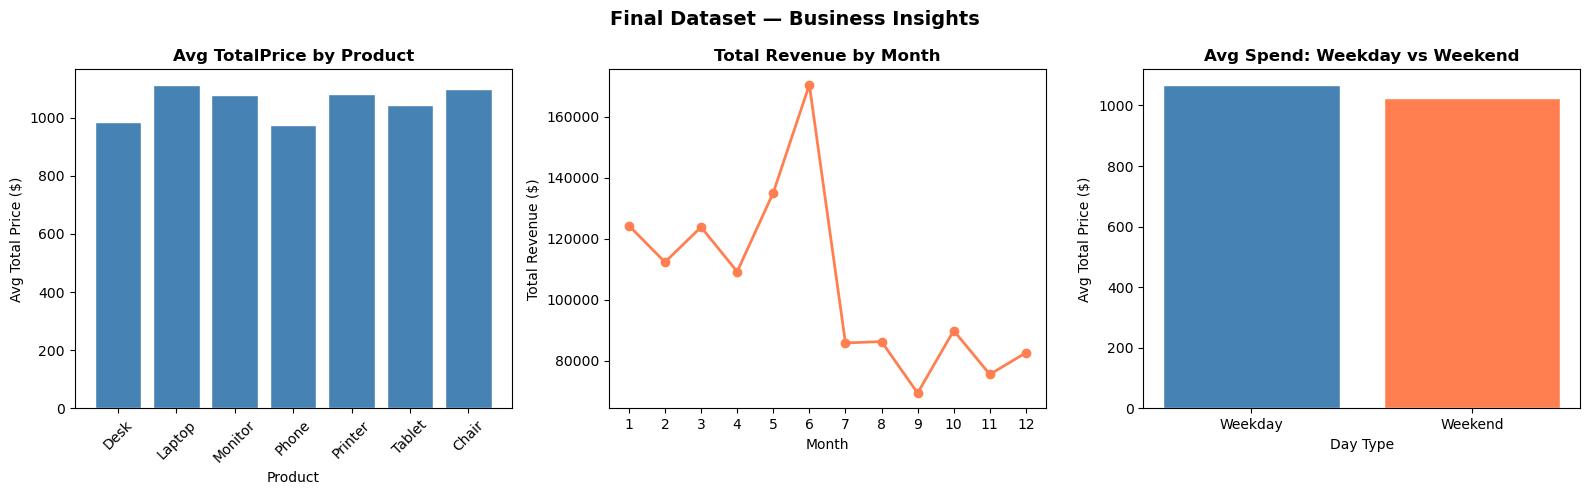


📸 Screenshot saved → screenshots/final_insights.png

🎉 PROJECT 1 COMPLETE — Full Pipeline Summary

📌 STEP 1 — Data Loading & Exploration
   → Loaded 1,200 rows × 14 columns
   → Identified CouponCode: 25.75% missing
   → Analyzed distributions and data types

🧹 STEP 2 — Data Cleaning
   → Dropped 4 identifier columns
   → Filled CouponCode NaN with 'No_Coupon'
   → Capped 8 outliers via IQR Winsorization
   → Extracted Year, Month, DayOfWeek, Quarter

⚙️  STEP 3 — Feature Engineering
   → Revenue_Per_Item    (TotalPrice / Quantity)
   → Is_Weekend          (Saturday or Sunday?)
   → Has_Coupon          (coupon used? 0/1)
   → Price_Quantity_Ratio (UnitPrice / Quantity)

🔢 STEP 4 — Encoding + Collinearity
   → One-Hot Encoded 5 categorical columns
   → Removed 3 redundant columns (corr > 0.80)
   → Final: 1,200 rows × 30 columns

✅ STEP 5 — Validation + Save
   → 9 Pandera schema rules validated ✅
   → Saved: outputs/dataset_clean.csv
   → Saved: outputs/dataset_clean.parquet

📸 Screen

In [10]:
# ============================================================
# STEP 5: DATA VALIDATION + SAVE
# ============================================================

print("=" * 60)
print("✅ STEP 5: VALIDATION + SAVE")
print("=" * 60)

# ----------------------------------------
# 5A. IMPORT PANDERA (new import style)
# ----------------------------------------
import pandera.pandas as pa
from pandera.pandas import Column, DataFrameSchema, Check
import os
os.environ["DISABLE_PANDERA_IMPORT_WARNING"] = "True"
print("\n✅ 5A — Pandera imported successfully!")

# ----------------------------------------
# 5B. DEFINE VALIDATION SCHEMA
# ----------------------------------------
print("\n📋 5B — Defining validation schema (data contracts)...")

schema = DataFrameSchema(
    {
        "Quantity": Column(
            int,
            Check.ge(1),
            nullable=False
        ),
        "UnitPrice": Column(
            float,
            Check.ge(0),
            nullable=False
        ),
        "ItemsInCart": Column(
            int,
            Check.ge(1),
            nullable=False
        ),
        "TotalPrice": Column(
            float,
            Check.ge(0),
            nullable=False
        ),
        "Year": Column(
            int,
            Check.isin([2023, 2024, 2025]),
            nullable=False
        ),
        "Month": Column(
            int,
            Check.between(1, 12),
            nullable=False
        ),
        "DayOfWeek": Column(
            int,
            Check.between(0, 6),
            nullable=False
        ),
        "Is_Weekend": Column(
            int,
            Check.isin([0, 1]),
            nullable=False
        ),
        "Price_Quantity_Ratio": Column(
            float,
            Check.ge(0),
            nullable=False
        ),
    }
)

print("   ✅ Schema defined with 9 validation rules!")

# ----------------------------------------
# 5C. VALIDATE THE DATASET
# ----------------------------------------
print("\n🔍 5C — Running validation...")

try:
    validated_df = schema.validate(df_encoded, lazy=True)
    print("   ✅ ALL CHECKS PASSED!")
    print("   Your dataset meets all quality contracts.")
    print("   It is ready for Machine Learning! 🚀")

except pa.errors.SchemaErrors as e:
    print("   ❌ Validation errors found:")
    print(e.failure_cases)

# ----------------------------------------
# 5D. SAVE THE DATASET
# ----------------------------------------
print("\n💾 5D — Saving clean dataset...")

csv_path = "outputs/dataset_clean.csv"
df_encoded.to_csv(csv_path, index=False)
print(f"   ✅ CSV saved     → {csv_path}")

parquet_path = "outputs/dataset_clean.parquet"
df_encoded.to_parquet(parquet_path, index=False)
print(f"   ✅ Parquet saved → {parquet_path}")

# ----------------------------------------
# 5E. FINAL BUSINESS INSIGHTS CHARTS
# ----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Avg TotalPrice by Product
product_cols = [c for c in df_encoded.columns if 'Product_' in c]
product_revenue = {}
for col in product_cols:
    product_name = col.replace('Product_', '')
    avg = df_encoded[df_encoded[col] == 1]['TotalPrice'].mean()
    product_revenue[product_name] = avg

base_mask = (df_encoded[product_cols] == 0).all(axis=1)
product_revenue['Chair'] = df_encoded[base_mask]['TotalPrice'].mean()

axes[0].bar(product_revenue.keys(),
            product_revenue.values(),
            color='steelblue', edgecolor='white')
axes[0].set_title('Avg TotalPrice by Product', fontweight='bold')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Avg Total Price ($)')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Revenue by Month
monthly = df_encoded.groupby('Month')['TotalPrice'].sum()
axes[1].plot(monthly.index, monthly.values,
             marker='o', color='coral', linewidth=2)
axes[1].set_title('Total Revenue by Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_xticks(range(1, 13))

# Chart 3: Weekend vs Weekday
weekend_avg = df_encoded.groupby('Is_Weekend')['TotalPrice'].mean()
axes[2].bar(['Weekday', 'Weekend'],
            weekend_avg.values,
            color=['steelblue', 'coral'],
            edgecolor='white')
axes[2].set_title('Avg Spend: Weekday vs Weekend', fontweight='bold')
axes[2].set_xlabel('Day Type')
axes[2].set_ylabel('Avg Total Price ($)')

plt.suptitle('Final Dataset — Business Insights',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("screenshots/final_insights.png", dpi=150)
plt.show()
print("\n📸 Screenshot saved → screenshots/final_insights.png")

# ----------------------------------------
# FINAL PROJECT SUMMARY
# ----------------------------------------
print(f"\n{'=' * 60}")
print(f"🎉 PROJECT 1 COMPLETE — Full Pipeline Summary")
print(f"{'=' * 60}")
print(f"""
📌 STEP 1 — Data Loading & Exploration
   → Loaded 1,200 rows × 14 columns
   → Identified CouponCode: 25.75% missing
   → Analyzed distributions and data types

🧹 STEP 2 — Data Cleaning
   → Dropped 4 identifier columns
   → Filled CouponCode NaN with 'No_Coupon'
   → Capped 8 outliers via IQR Winsorization
   → Extracted Year, Month, DayOfWeek, Quarter

⚙️  STEP 3 — Feature Engineering
   → Revenue_Per_Item    (TotalPrice / Quantity)
   → Is_Weekend          (Saturday or Sunday?)
   → Has_Coupon          (coupon used? 0/1)
   → Price_Quantity_Ratio (UnitPrice / Quantity)

🔢 STEP 4 — Encoding + Collinearity
   → One-Hot Encoded 5 categorical columns
   → Removed 3 redundant columns (corr > 0.80)
   → Final: 1,200 rows × 30 columns

✅ STEP 5 — Validation + Save
   → 9 Pandera schema rules validated ✅
   → Saved: outputs/dataset_clean.csv
   → Saved: outputs/dataset_clean.parquet

📸 Screenshots for GitHub:
   → missing_values_heatmap.png
   → numeric_distributions.png
   → outliers_before_after.png
   → engineered_features.png
   → correlation_heatmap.png
   → final_insights.png
""")
print(f"{'=' * 60}")
print(f"👩‍💻 Author: Imen Hammami | DecodeLabs Intern 2026")
print(f"🔗 https://imenhammami.netlify.app")
print(f"{'=' * 60}")

In [11]:
# ============================================================
# STEP 5 FIX: Convert int32 → int64 for Pandera validation
# ------------------------------------------------------------

print("🔧 Fixing dtype mismatch: int32 → int64")

cols_to_fix = ['Year', 'Month', 'DayOfWeek']
for col in cols_to_fix:
    df_encoded[col] = df_encoded[col].astype('int64')
    print(f"   ✅ {col}: int32 → int64")

# Re-run validation
print("\n🔍 Re-running Pandera validation...")

try:
    validated_df = schema.validate(df_encoded, lazy=True)
    print("\n✅ ALL 9 CHECKS PASSED!")
    print("   Zero errors. Dataset is production-ready! 🚀")

except pa.errors.SchemaErrors as e:
    print("❌ Errors still found:")
    print(e.failure_cases)

print(f"\n{'=' * 60}")
print(f"🎉 PROJECT 1 — 100% COMPLETE!")
print(f"   ✅ 1,200 rows | 30 columns | 0 errors")
print(f"   ✅ CSV  → outputs/dataset_clean.csv")
print(f"   ✅ Parquet → outputs/dataset_clean.parquet")
print(f"   ✅ 6 screenshots saved for GitHub")
print(f"{'=' * 60}")

🔧 Fixing dtype mismatch: int32 → int64
   ✅ Year: int32 → int64
   ✅ Month: int32 → int64
   ✅ DayOfWeek: int32 → int64

🔍 Re-running Pandera validation...

✅ ALL 9 CHECKS PASSED!
   Zero errors. Dataset is production-ready! 🚀

🎉 PROJECT 1 — 100% COMPLETE!
   ✅ 1,200 rows | 30 columns | 0 errors
   ✅ CSV  → outputs/dataset_clean.csv
   ✅ Parquet → outputs/dataset_clean.parquet
   ✅ 6 screenshots saved for GitHub
